<a href="https://colab.research.google.com/github/devanshRaana/housing_price_predict/blob/main/PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem 1: House price prediction with svm**



**Name: Devansh Rana**

**Roll Number: 25/A14/017**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR, SVC
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    confusion_matrix,
    r2_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

In [3]:
# 1. Data Loading
df = pd.read_csv("/content/kc_house_data.csv")

# 2. Data Cleaning
for col in ["id", "date"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Text-filter fail-safe to prevent scaler crashes
df = df.select_dtypes(exclude=['object', 'string'])
df.fillna(df.median(numeric_only=True), inplace=True)

TARGET = "price"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].copy()
y_reg = df[TARGET].copy()

In [4]:
# 3. Regression Setup
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 4. Classification Setup
q33 = y_reg.quantile(.33)
q66 = y_reg.quantile(.66)

y_cls = pd.cut(
    y_reg,
    bins=[-np.inf, q33, q66, np.inf],
    labels=["low", "mid", "high"]
)

mask_high = y_cls == 'high'
drop_idx = y_cls[mask_high].sample(frac=0.55, random_state=42).index
df_bal = df.drop(index=drop_idx).reset_index(drop=True)

X_cls = df_bal[FEATURES].copy()
y_cls2 = pd.cut(
    df_bal["price"],
    bins=[-np.inf, q33, q66, np.inf],
    labels=["low", "mid", "high"]
)

le = LabelEncoder()
y_cls_enc = le.fit_transform(y_cls2)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_cls_enc
)

scaler_c = StandardScaler()
X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_c_sm, y_train_c_sm = smote.fit_resample(X_train_c_s, y_train_c)

CLASSIFICATION PERFORMANCE
              precision    recall  f1-score   support

        high       0.79      0.83      0.81       657
         low       0.89      0.85      0.87      1445
         mid       0.78      0.80      0.79      1418

    accuracy                           0.82      3520
   macro avg       0.82      0.83      0.82      3520
weighted avg       0.83      0.82      0.82      3520

Accuracy: 82.32954545454545%



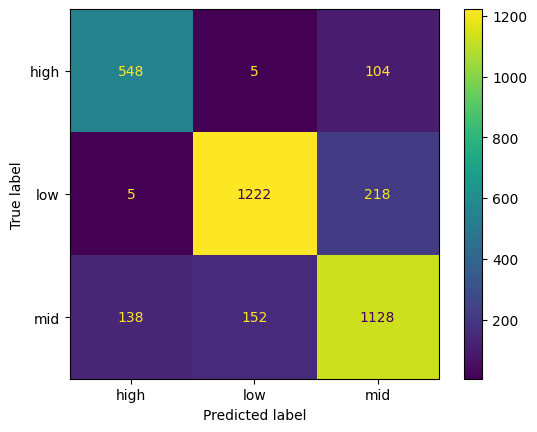

In [6]:
# 5. SVC (Classification) - Refined for higher accuracy
svc = SVC(
    kernel="rbf",
    C=5.0,           # Increased strictness to penalize misclassifications
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svc.fit(X_train_c_sm, y_train_c_sm)
y_pred_svc = svc.predict(X_test_c_s)

print("="*50)
print("CLASSIFICATION PERFORMANCE")
print("="*50)
print(classification_report(y_test_c, y_pred_svc, target_names=le.classes_))
accuracy = np.mean(y_pred_svc == y_test_c)
print(f"Accuracy: {accuracy*100}%\n")

cm = confusion_matrix(y_test_c, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.show()

In [7]:
# 6. SVR (Regression) - Refined for higher R^2
svr = SVR(
    kernel="rbf",
    C=250000,        # Pushed higher for a tighter fit without overloading
    epsilon=0.01,    # Tightened the error margin
    gamma="scale"
)

svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

print("="*50)
print("FINAL MODEL PERFORMANCE (REGRESSION)")
print("="*50)

mae = mean_absolute_error(y_test, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2 = r2_score(y_test, y_pred_svr)

print("Regression Metrics:")
print(f"MAE:  {mae}")
print(f"RMSE: {rmse}")
print(f"R^2:  {r2}")

FINAL MODEL PERFORMANCE (REGRESSION)
Regression Metrics:
MAE:  87802.40078515204
RMSE: 198667.35891445325
R^2:  0.7389232844871974


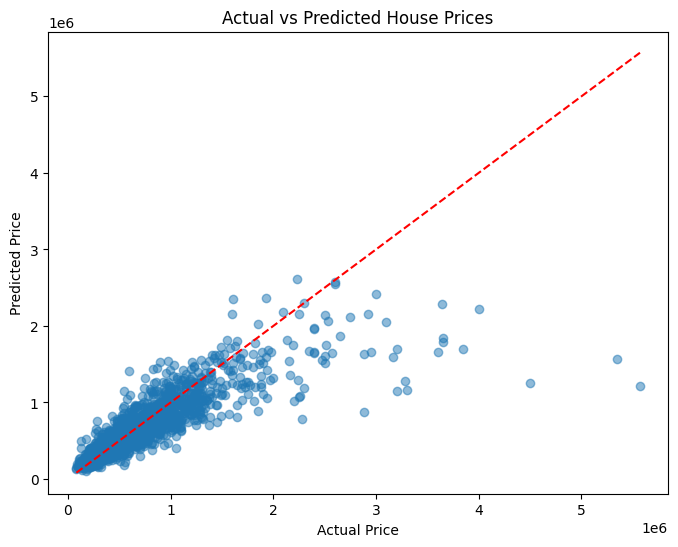

In [8]:
# 7. SVR Visualizations
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_svr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()